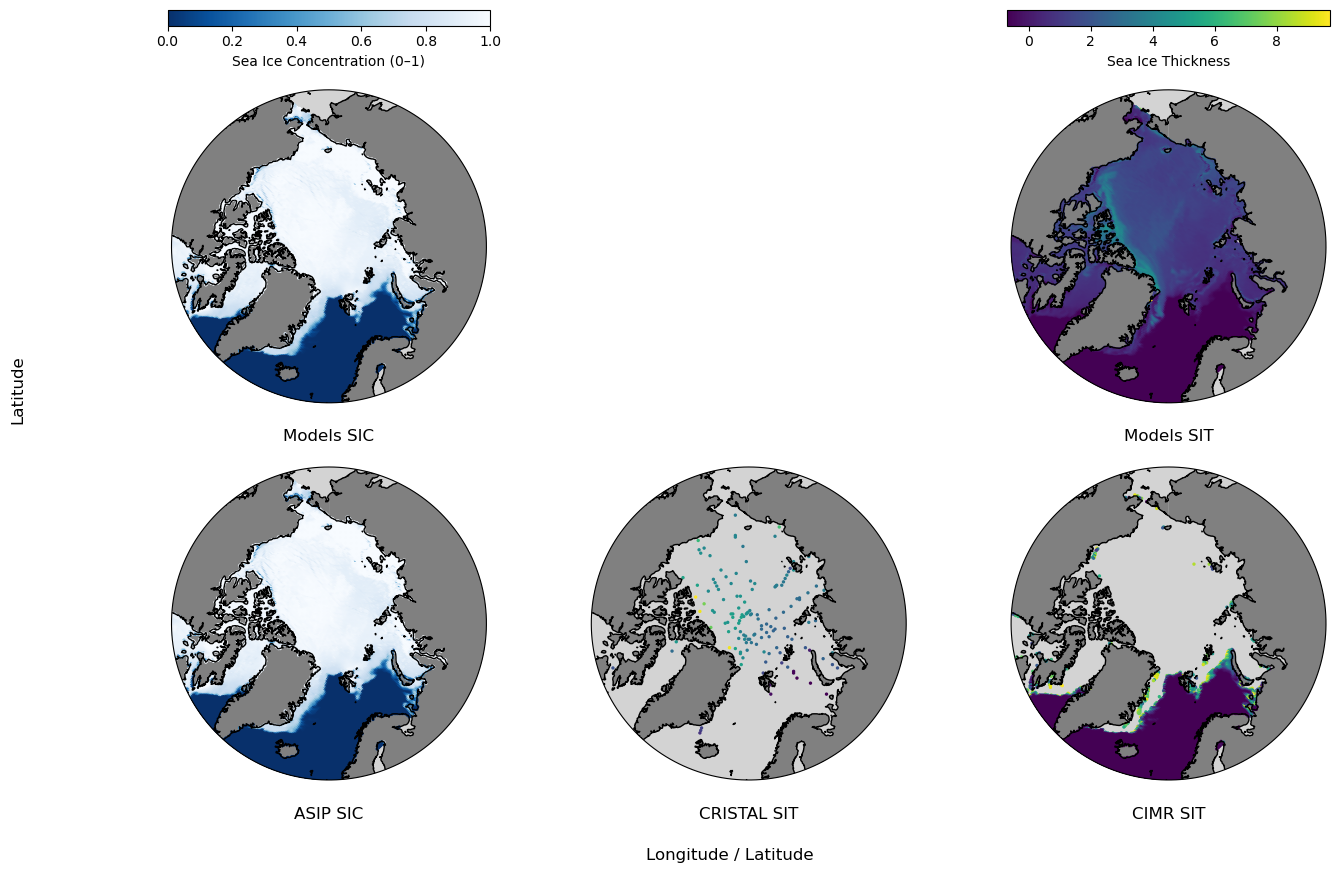

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.path import Path
from matplotlib.gridspec import GridSpec
import os
os.environ['HDF5_USE_FILE_LOCKING']='FALSE'


# -----------------------------
# FILE
# -----------------------------
file_obs = "/data/users/maxb/PREPROC/preproc_CROSCIM_x50.nc"
ds = xr.open_dataset(file_obs)

sample_idx = 0

# -----------------------------
# SELECT DATA
# -----------------------------
# MODELS (final timestep)
models_SIC = ds["models_SIC"].isel(record=sample_idx, sample=0, time=-1).values
models_SIT = ds["models_SIT"].isel(record=sample_idx, sample=0, time=-1).values

# OBS (mean over time)
cristal = ds["cristal_SIT"].isel(record=sample_idx, sample=0).mean(dim="time", skipna=True).values
cimr    = ds["cimr_SIT"].isel(record=sample_idx, sample=0).mean(dim="time", skipna=True).values
asip    = ds["asip_sic"].isel(record=sample_idx, sample=0).mean(dim="time", skipna=True).values
cristal = ds["cristal_SIT"].isel(record=sample_idx, sample=0, time=-1).values
cimr    = ds["cimr_SIT"].isel(record=sample_idx, sample=0, time=-1).values
asip    = ds["tgt_SIC"].isel(record=sample_idx, sample=0, time=-1).values

# LAT/LON
lon = ds["lon"].isel(record=sample_idx, sample=0).values
lat = ds["lat"].isel(record=sample_idx, sample=0).values

# -----------------------------
# DENORMALIZE
# -----------------------------
def maybe_denorm(lon, lat):
    if np.nanmax(lon) <= 1.5:
        lon = lon * 360.0 - 180.0
    if np.nanmax(lat) <= 1.5:
        lat = lat * 40.0 + 50.0
    return lon, lat

lon, lat = maybe_denorm(lon, lat)

# -----------------------------
# CIRCULAR BOUNDARY
# -----------------------------
theta = np.linspace(0, 2*np.pi, 200)
center = [0.5, 0.5]
radius = 0.5
verts = np.vstack([np.sin(theta)*radius + center[0],
                   np.cos(theta)*radius + center[1]]).T
circle_path = Path(verts)

# -----------------------------
# PLOT HELPERS
# -----------------------------
def setup_ax(ax):
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='gray')
    ax.set_facecolor('lightgray')
    ax.set_boundary(circle_path, transform=ax.transAxes)

def scatter_plot(ax, lon, lat, data, cmap, vmin=None, vmax=None):
    mask = np.isfinite(data)
    return ax.scatter(
        lon[mask], lat[mask],
        c=data[mask],
        s=2,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

# -----------------------------
# FIGURE + GRIDSPEC
# -----------------------------
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 3, figure=fig, height_ratios=[0.05, 1, 1], hspace=0.3, wspace=0.3)

# --- Top row: Models
ax0 = fig.add_subplot(gs[1, 0], projection=ccrs.NorthPolarStereo())  # left column
ax1 = fig.add_subplot(gs[1, 2], projection=ccrs.NorthPolarStereo())  # right column

axes_top = [ax0, ax1]
for ax in axes_top:
    setup_ax(ax)

sc0 = scatter_plot(ax0, lon, lat, models_SIC, "Blues_r", vmin=0, vmax=1)
ax0.set_title("Models SIC", y=-0.15)
sc1 = scatter_plot(ax1, lon, lat, models_SIT, "viridis")
ax1.set_title("Models SIT", y=-0.15)

# --- Top colorbars (row 0)
cbar_ax_sic = fig.add_subplot(gs[0, 0])
cbar0 = fig.colorbar(sc0, cax=cbar_ax_sic, orientation='horizontal')
cbar0.set_label("Sea Ice Concentration (0–1)")

cbar_ax_sit = fig.add_subplot(gs[0, 2])
cbar1 = fig.colorbar(sc1, cax=cbar_ax_sit, orientation='horizontal')
cbar1.set_label("Sea Ice Thickness")

# --- Bottom row: Observations
ax2 = fig.add_subplot(gs[2, 0], projection=ccrs.NorthPolarStereo())
ax3 = fig.add_subplot(gs[2, 1], projection=ccrs.NorthPolarStereo())
ax4 = fig.add_subplot(gs[2, 2], projection=ccrs.NorthPolarStereo())

axes_bottom = [ax2, ax3, ax4]
for ax in axes_bottom:
    setup_ax(ax)

sc2 = scatter_plot(ax2, lon, lat, asip, "Blues_r", vmin=0, vmax=1)
ax2.set_title("ASIP SIC", y=-0.15)
sc3 = scatter_plot(ax3, lon, lat, cristal, "viridis")
ax3.set_title("CRISTAL SIT", y=-0.15)
sc4 = scatter_plot(ax4, lon, lat, cimr, "viridis")
ax4.set_title("CIMR SIT", y=-0.15)

# --- Bottom labels
fig.text(0.5, 0.03, 'Longitude / Latitude', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'Latitude', va='center', rotation='vertical', fontsize=12)

plt.show()

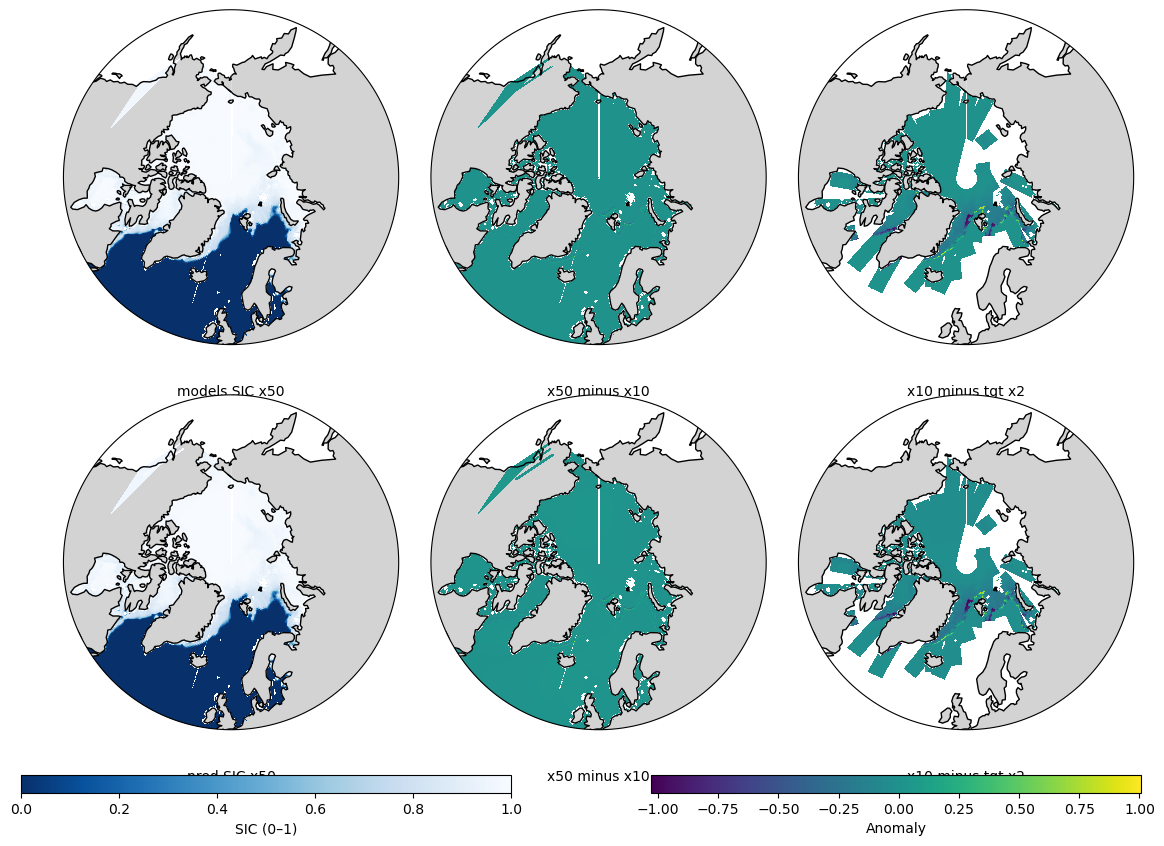

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.path import Path

# -----------------------------
# Paths
# -----------------------------
base = "/dmidata/users/maxb/results/lightning_logs/version_73714/"
f_x50 = base + "test_data_20210201_20210215_patch_x50.nc"
f_x10 = base + "test_data_20210206_20210215_patch_x10.nc"
f_x2  = base + "test_data_20210211_20210215_patch_x2.nc"

# -----------------------------
# Load datasets
# -----------------------------
ds50 = xr.open_dataset(f_x50)
ds10 = xr.open_dataset(f_x10)
ds2  = xr.open_dataset(f_x2)

# -----------------------------
# Get grids
# -----------------------------
lon2, lat2 = ds2["lon"], ds2["lat"]
lon50, lat50 = ds50["lon"], ds50["lat"]
lon10, lat10 = ds10["lon"], ds10["lat"]

# -----------------------------
# Helper
# -----------------------------
def get_var(ds, name1, name2):
    return ds[name1] if name1 in ds else ds[name2]

# -----------------------------
# Final timestep
# -----------------------------
models50 = get_var(ds50, "models_SIC", "tgt_SIC").isel(time=-1)
models10 = get_var(ds10, "models_SIC", "tgt_SIC").isel(time=-1)
tgt2     = get_var(ds2,  "models_SIC", "tgt_SIC").isel(time=-1) / 100.0

pred50 = ds50["pred_SIC"].isel(time=-1)
pred10 = ds10["pred_SIC"].isel(time=-1)

# -----------------------------
# Fast regrid (griddata)
# -----------------------------
def regrid(lon_src, lat_src, data_src):
    return griddata(
        (lon_src.values.ravel(), lat_src.values.ravel()),
        data_src.values.ravel(),
        (lon2.values, lat2.values),
        method="linear"
    )

models50_i = regrid(lon50, lat50, models50)
models10_i = regrid(lon10, lat10, models10)
pred50_i   = regrid(lon50, lat50, pred50)
pred10_i   = regrid(lon10, lat10, pred10)

# Wrap
coords = {"yc": ds2.yc, "xc": ds2.xc}
models50_i = xr.DataArray(models50_i, coords=coords)
models10_i = xr.DataArray(models10_i, coords=coords)
pred50_i   = xr.DataArray(pred50_i, coords=coords)
pred10_i   = xr.DataArray(pred10_i, coords=coords)

# -----------------------------
# Anomalies
# -----------------------------
anom_models_50_10 = models50_i - models10_i
anom_models_10_2  = models10_i - tgt2

anom_pred_50_10 = pred50_i - pred10_i
anom_pred_10_2  = pred10_i - tgt2

# Shared anomaly range
all_anoms = xr.concat([
    anom_models_50_10, anom_models_10_2,
    anom_pred_50_10, anom_pred_10_2
], dim="stack")

vmin = float(all_anoms.min())
vmax = float(all_anoms.max())

# -----------------------------
# Circular boundary
# -----------------------------
theta = np.linspace(0, 2*np.pi, 200)
center = [0.5, 0.5]
radius = 0.5
verts = np.vstack([
    np.sin(theta)*radius + center[0],
    np.cos(theta)*radius + center[1]
]).T
circle = Path(verts)

# -----------------------------
# Plot setup
# -----------------------------
fig = plt.figure(figsize=(14, 9))
proj = ccrs.NorthPolarStereo()

axes = []
for i in range(2):
    for j in range(3):
        ax = plt.subplot(2, 3, i*3 + j + 1, projection=proj)
        ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
        ax.coastlines()
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.set_boundary(circle, transform=ax.transAxes)
        axes.append(ax)

axes = np.array(axes).reshape(2,3)

# -----------------------------
# Colormaps
# -----------------------------
cmap_sic = "Blues_r"
cmap_anom = "viridis"

# -----------------------------
# Row 1 (models)
# -----------------------------
im0 = axes[0,0].pcolormesh(lon2, lat2, models50_i,
                          transform=ccrs.PlateCarree(),
                          cmap=cmap_sic, vmin=0, vmax=1)

im1 = axes[0,1].pcolormesh(lon2, lat2, anom_models_50_10,
                          transform=ccrs.PlateCarree(),
                          cmap=cmap_anom, vmin=vmin, vmax=vmax)

im2 = axes[0,2].pcolormesh(lon2, lat2, anom_models_10_2,
                          transform=ccrs.PlateCarree(),
                          cmap=cmap_anom, vmin=vmin, vmax=vmax)

# -----------------------------
# Row 2 (pred)
# -----------------------------
im3 = axes[1,0].pcolormesh(lon2, lat2, pred50_i,
                          transform=ccrs.PlateCarree(),
                          cmap=cmap_sic, vmin=0, vmax=1)

im4 = axes[1,1].pcolormesh(lon2, lat2, anom_pred_50_10,
                          transform=ccrs.PlateCarree(),
                          cmap=cmap_anom, vmin=vmin, vmax=vmax)

im5 = axes[1,2].pcolormesh(lon2, lat2, anom_pred_10_2,
                          transform=ccrs.PlateCarree(),
                          cmap=cmap_anom, vmin=vmin, vmax=vmax)

# -----------------------------
# Titles (BOTTOM, clean)
# -----------------------------
titles = [
    ["models SIC x50", "x50 minus x10", "x10 minus tgt x2"],
    ["pred SIC x50",   "x50 minus x10", "x10 minus tgt x2"]
]

for i in range(2):
    for j in range(3):
        axes[i,j].text(0.5, -0.12, titles[i][j],
                       transform=axes[i,j].transAxes,
                       ha='center', va='top', fontsize=10)

# -----------------------------
# Colorbars (HORIZONTAL BELOW)
# -----------------------------
cbar_ax1 = fig.add_axes([0.1, 0.08, 0.35, 0.02])
cbar1 = fig.colorbar(im0, cax=cbar_ax1, orientation='horizontal')
cbar1.set_label("SIC (0–1)")

cbar_ax2 = fig.add_axes([0.55, 0.08, 0.35, 0.02])
cbar2 = fig.colorbar(im1, cax=cbar_ax2, orientation='horizontal')
cbar2.set_label("Anomaly")

# -----------------------------
# Layout
# -----------------------------
plt.subplots_adjust(top=0.95, bottom=0.15, wspace=0.05, hspace=0.15)

plt.show()

Load: 0.03s
Global coarsen: 0.79s
Global coarsen: 0.79s
Anomalies: 2.71s
Anomalies: 2.71s
  Zoom 'Barents Sea': 3.84s
  Zoom 'Barents Sea': 3.84s
  Zoom 'Kara Sea': 3.96s
  Zoom 'Kara Sea': 3.96s
  Zoom 'Greenland / Fram': 4.47s
Zoom total: 12.49s
  Zoom 'Greenland / Fram': 4.47s
Zoom total: 12.49s
Plotting: 13.76s

TOTAL: 30.48s
Plotting: 13.76s

TOTAL: 30.48s


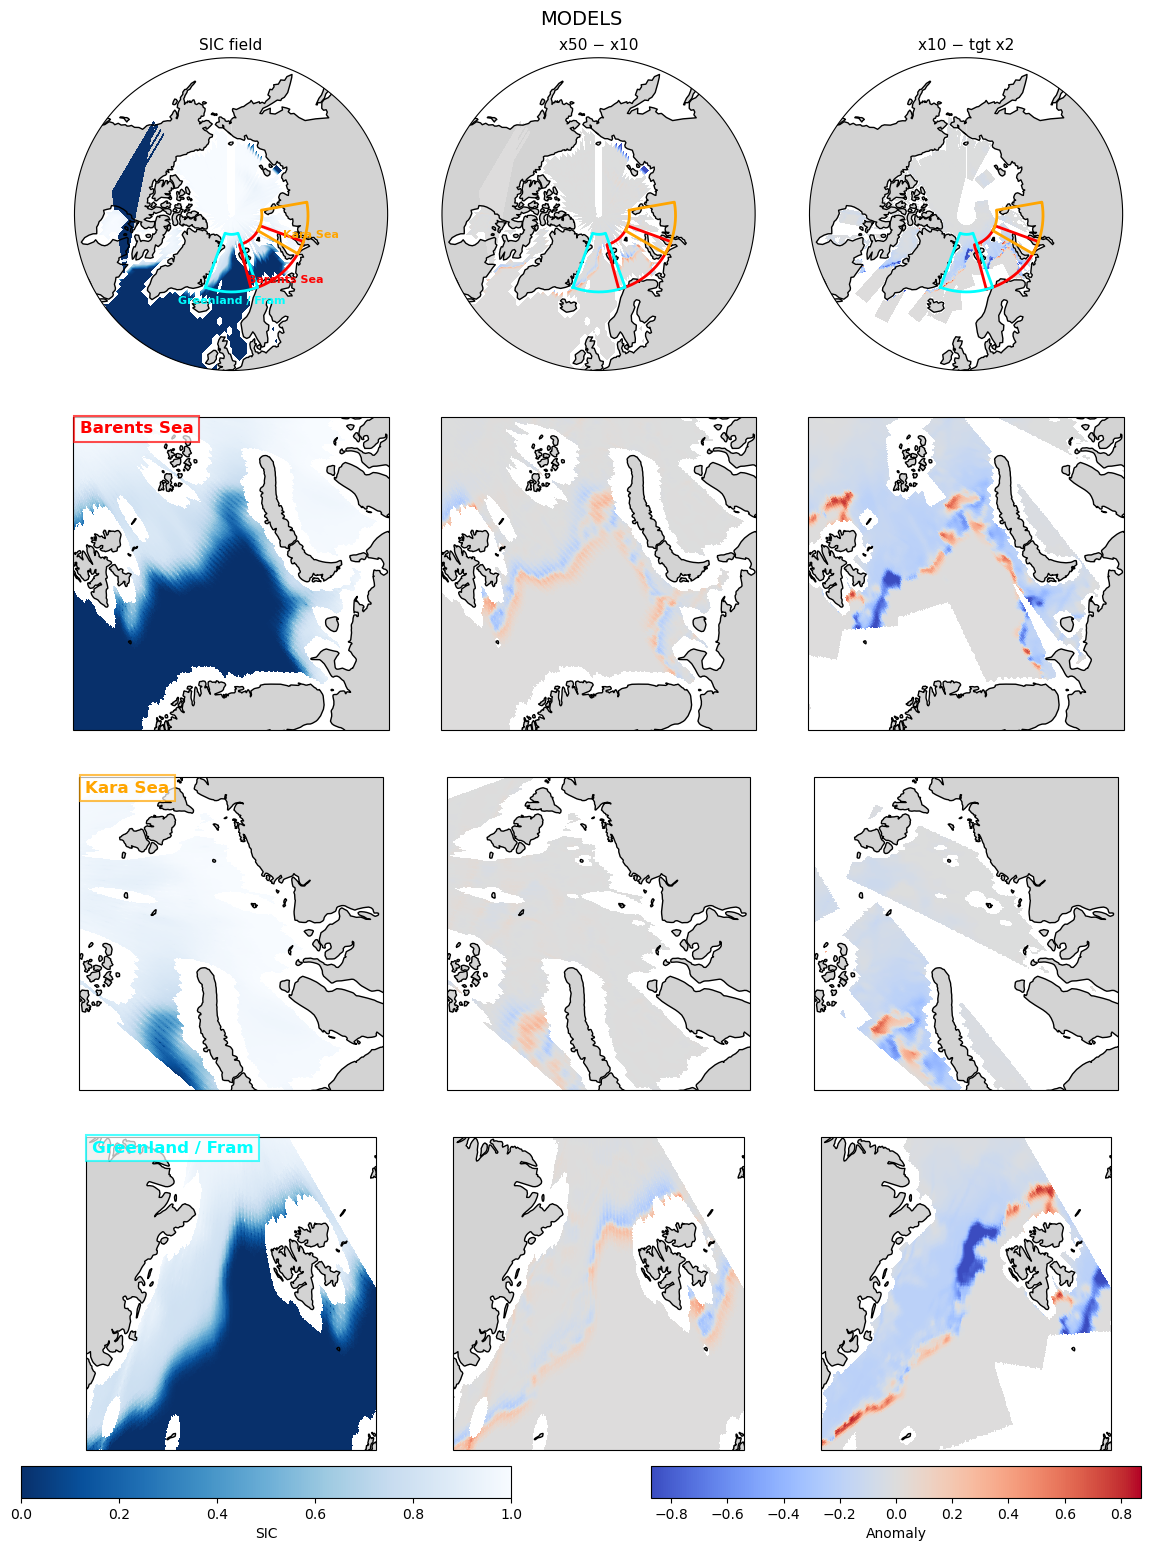

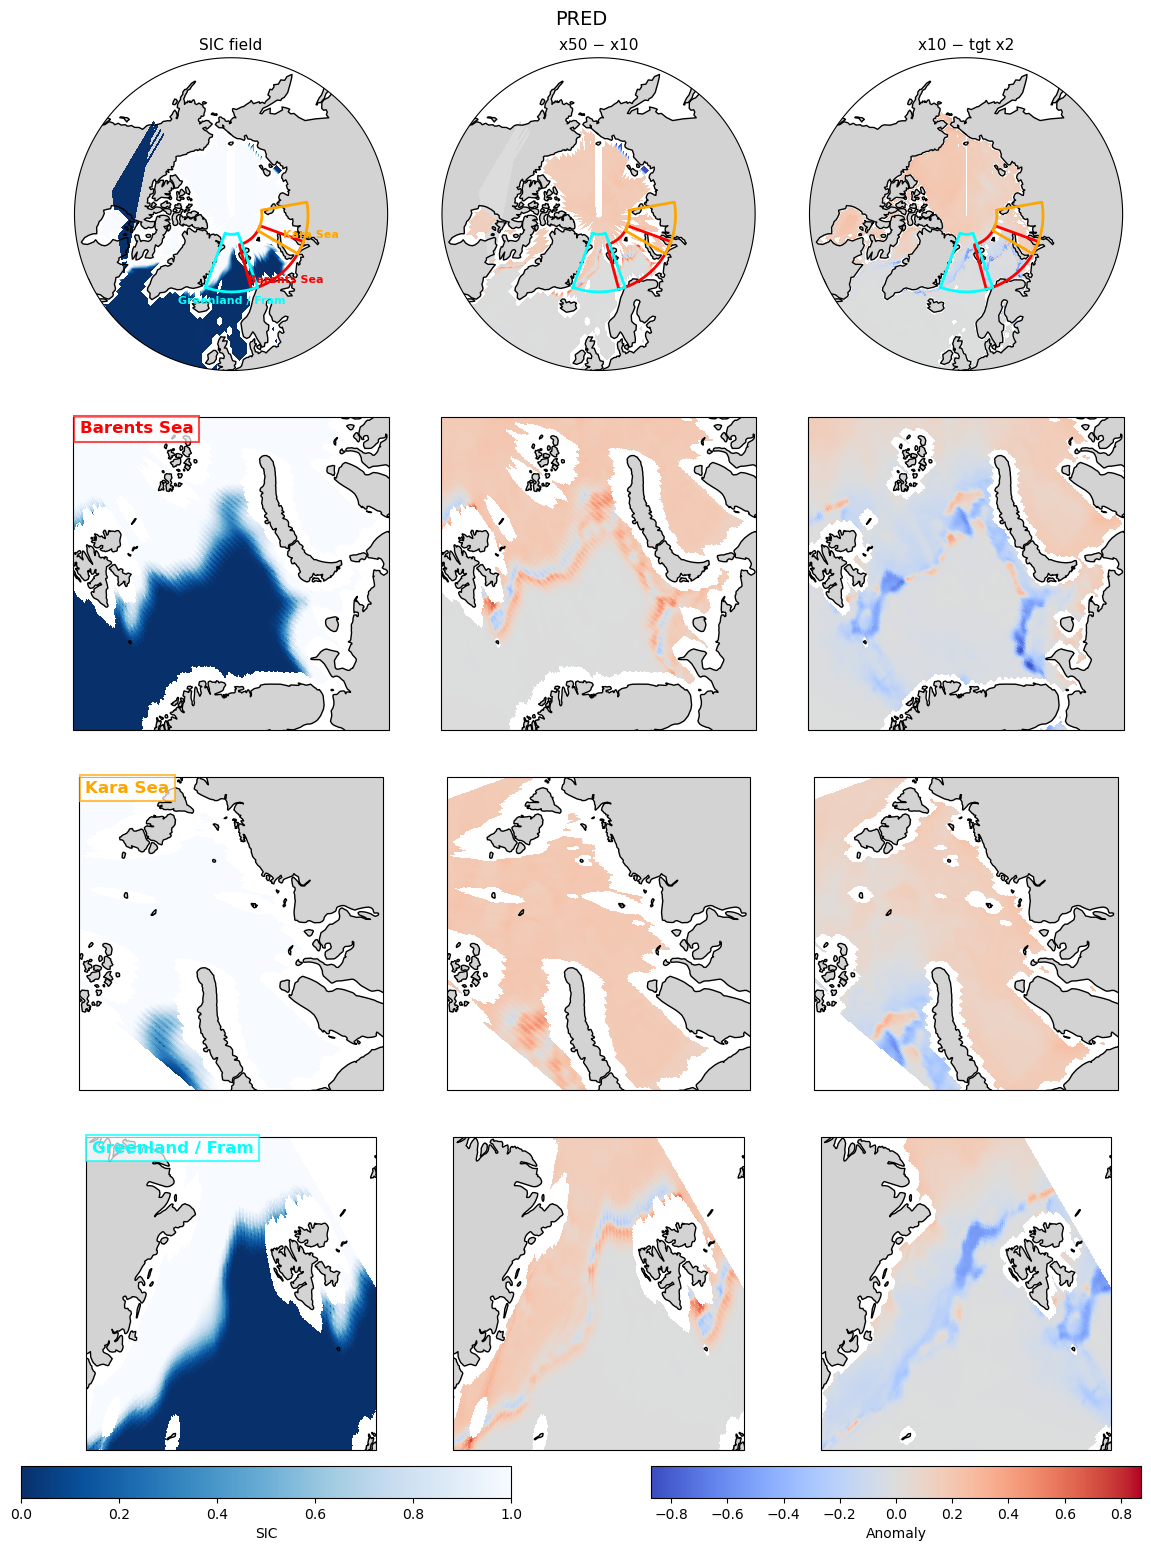

In [20]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.path import Path
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
import time

target_t = -1
t_total = time.time()

# -----------------------------
# PATHS
# -----------------------------
base = "/dmidata/users/maxb/results/lightning_logs/version_75990/"
f_x50 = base + "test_data_20210201_20210215_patch_x50.nc"
f_x10 = base + "test_data_20210206_20210215_patch_x10.nc"
f_x2  = base + "test_data_20210211_20210215_patch_x2.nc"

# -----------------------------
# LOAD DATA (eager, only needed vars)
# -----------------------------
t0 = time.time()
needed_vars = ["lon", "lat", "models_SIC", "tgt_SIC", "pred_SIC"]

def load_ds(path):
    ds = xr.open_dataset(path)
    return ds[[v for v in needed_vars if v in ds]]

ds50 = load_ds(f_x50)
ds10 = load_ds(f_x10)
ds2  = load_ds(f_x2)
print(f"Load: {time.time()-t0:.2f}s")

def get_var(ds, a, b):
    return ds[a] if a in ds else ds[b]

# -----------------------------
# GRIDS (numpy, computed once)
# -----------------------------
lon2 = ds2["lon"].values
lat2 = ds2["lat"].values
lon2 = (lon2 + 180) % 360 - 180
lon50 = ds50["lon"].values; lat50 = ds50["lat"].values
lon10 = ds10["lon"].values; lat10 = ds10["lat"].values

# -----------------------------
# GLOBAL: coarsen each grid independently (no regridding)
# -----------------------------
t0 = time.time()

def coarsen_field(ds, var, f=4):
    da = get_var(ds, var, "tgt_SIC").isel(time=target_t).values
    ny, nx = da.shape
    return da[:ny-ny%f, :nx-nx%f].reshape(ny//f, f, nx//f, f).mean(axis=(1,3))

def coarsen_grid(arr, f=4):
    ny, nx = arr.shape
    return arr[:ny-ny%f, :nx-nx%f].reshape(ny//f, f, nx//f, f).mean(axis=(1,3))

models50_g = coarsen_field(ds50, "models_SIC")
models10_g = coarsen_field(ds10, "models_SIC")
pred50_g   = coarsen_field(ds50, "pred_SIC")
pred10_g   = coarsen_field(ds10, "pred_SIC")
tgt2_g     = coarsen_field(ds2, "tgt_SIC") / 100.0
pred2_g     = coarsen_field(ds2, "pred_SIC") / 100.0

lon2_g  = coarsen_grid(lon2);  lat2_g  = coarsen_grid(lat2)
lon50_g = coarsen_grid(lon50); lat50_g = coarsen_grid(lat50)
lon10_g = coarsen_grid(lon10); lat10_g = coarsen_grid(lat10)

print(f"Global coarsen: {time.time()-t0:.2f}s")

# -----------------------------
# ANOMALIES: regrid coarsened 50/10 → coarsened x2 grid
# -----------------------------
t0 = time.time()

def regrid_coarsened(lon_s, lat_s, data_s, lon_t, lat_t):
    return griddata((lon_s.ravel(), lat_s.ravel()), data_s.ravel(),
                    (lon_t, lat_t), method="linear")

models50_on2 = regrid_coarsened(lon50_g, lat50_g, models50_g, lon2_g, lat2_g)
models10_on2 = regrid_coarsened(lon10_g, lat10_g, models10_g, lon2_g, lat2_g)
pred50_on2   = regrid_coarsened(lon50_g, lat50_g, pred50_g,   lon2_g, lat2_g)
pred10_on2   = regrid_coarsened(lon10_g, lat10_g, pred10_g,   lon2_g, lat2_g)

anom_models_50_10 = models50_on2 - models10_on2
anom_models_10_2  = models10_on2 - tgt2_g
anom_pred_50_10   = pred50_on2 - pred10_on2
anom_pred_10_2    = pred10_on2 - pred2_g

all_anoms = np.concatenate([a.ravel() for a in [anom_models_50_10, anom_models_10_2,
                                                 anom_pred_50_10, anom_pred_10_2]])
vmin = float(-1.*np.nanmax(all_anoms))
vmax = float(np.nanmax(all_anoms))
print(f"Anomalies: {time.time()-t0:.2f}s")

# -----------------------------
# REGIONS
# -----------------------------
regions = {
    "Barents Sea": [15, 70, 70, 82],
    "Kara Sea": [60, 100, 70, 82],
    "Greenland / Fram": [-20, 20, 70, 85]
}
region_colors = {
    "Barents Sea": "red",
    "Kara Sea": "orange",
    "Greenland / Fram": "cyan"
}

# -----------------------------
# ZOOM: crop + KDTree IDW interpolation
# Use large padding so data fills the full projected subplot extent
# -----------------------------
t0 = time.time()

def make_zoom_grid(extent, pad=10, npts=500):
    """Build output grid with generous padding beyond the extent
    so that data fills the full projected subplot view."""
    lons = np.linspace(extent[0] - pad, extent[1] + pad, npts)
    lats = np.linspace(max(extent[2] - pad, 50), min(extent[3] + pad, 90), npts)
    return np.meshgrid(lons, lats)

def crop_mask(lon, lat, extent, pad=12):
    return ((lat >= extent[2]-pad) & (lat <= extent[3]+pad) &
            (lon >= extent[0]-pad) & (lon <= extent[1]+pad))

def idw_interp(lon_s, lat_s, data_s, lon_t, lat_t, k=20):
    tree = cKDTree(np.column_stack([lon_s, lat_s]))
    dists, idx = tree.query(np.column_stack([lon_t.ravel(), lat_t.ravel()]), k=k)
    dists = np.maximum(dists, 1e-10)
    weights = 1.0 / dists
    weights /= weights.sum(axis=1, keepdims=True)
    result = (data_s[idx] * weights).sum(axis=1)
    return result.reshape(lon_t.shape)

def regrid_zoom(lon_s, lat_s, data_s, extent, max_src_pts=500_000):
    mask = crop_mask(lon_s, lat_s, extent)
    lo, la, d = lon_s[mask], lat_s[mask], data_s[mask]
    if len(lo) > max_src_pts:
        step = len(lo) // max_src_pts + 1
        lo, la, d = lo[::step], la[::step], d[::step]
    lon_out, lat_out = make_zoom_grid(extent)
    return idw_interp(lo, la, d, lon_out, lat_out), lon_out, lat_out

# Extract fields at last timestep as numpy (once)
m50_full = get_var(ds50, "models_SIC", "tgt_SIC").isel(time=target_t).values
m10_full = get_var(ds10, "models_SIC", "tgt_SIC").isel(time=target_t).values
tgt_full = get_var(ds2,  "tgt_SIC", "models_SIC").isel(time=target_t).values / 100.0
p50_full = ds50["pred_SIC"].isel(time=target_t).values
p10_full = ds10["pred_SIC"].isel(time=target_t).values
pred_full = ds2["pred_SIC"].isel(time=target_t).values / 100.0

zoom_data = {}
for name, ext in regions.items():
    t_r = time.time()
    m50_z, zlon, zlat = regrid_zoom(lon50, lat50, m50_full, ext)
    m10_z, _, _       = regrid_zoom(lon10, lat10, m10_full, ext)
    tgt_z, _, _       = regrid_zoom(lon2,  lat2,  tgt_full, ext)
    p50_z, _, _       = regrid_zoom(lon50, lat50, p50_full, ext)
    p10_z, _, _       = regrid_zoom(lon10, lat10, p10_full, ext)
    pred_z, _, _       = regrid_zoom(lon2, lat2, pred_full, ext)

    zoom_data[name] = dict(
        main=m50_z, a1=m50_z - m10_z, a2=m10_z - tgt_z,
        p_main=p50_z, p_a1=p50_z - p10_z, p_a2=p10_z - pred_z,
        lon=zlon, lat=zlat
    )
    print(f"  Zoom '{name}': {time.time()-t_r:.2f}s")
print(f"Zoom total: {time.time()-t0:.2f}s")

# -----------------------------
# PLOT HELPERS
# -----------------------------
t0 = time.time()
theta = np.linspace(0, 2*np.pi, 200)
circle = Path(np.vstack([np.sin(theta)*0.5+0.5, np.cos(theta)*0.5+0.5]).T)
proj = ccrs.NorthPolarStereo()

def setup_ax(ax, extent=None):
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    else:
        ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
        ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")

def pcolor(ax, lon, lat, data, cmap, vmin, vmax):
    return ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                         cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")

def draw_region_box(ax, extent, color, label=None, lw=2):
    """Draw a region bounding box on a polar stereographic map."""
    npts = 50
    lons_bottom = np.linspace(extent[0], extent[1], npts)
    lons_top    = np.linspace(extent[1], extent[0], npts)
    lats_left   = np.linspace(extent[2], extent[3], npts)
    lats_right  = np.linspace(extent[3], extent[2], npts)

    # Build closed polygon: bottom → right → top → left
    box_lons = np.concatenate([
        lons_bottom,                                    # bottom edge
        np.full(npts, extent[1]),                       # right edge
        lons_top,                                       # top edge
        np.full(npts, extent[0]),                       # left edge
    ])
    box_lats = np.concatenate([
        np.full(npts, extent[2]),                       # bottom edge
        lats_left,                                      # right edge
        np.full(npts, extent[3]),                       # top edge
        lats_right,                                     # left edge
    ])
    ax.plot(box_lons, box_lats, color=color, linewidth=lw,
            transform=ccrs.PlateCarree(), zorder=10)
    if label:
        mid_lon = (extent[0] + extent[1]) / 2
        ax.text(mid_lon, extent[2] - 1, label, color=color,
                fontsize=8, fontweight="bold", ha="center", va="top",
                transform=ccrs.PlateCarree(), zorder=11)

# -----------------------------
# FIGURE FUNCTION
# -----------------------------
def make_figure(main, a1, a2, title, zoom_dict=None, kind="models"):
    fig, axes = plt.subplots(4, 3, figsize=(14, 16), subplot_kw={"projection": proj})

    # --- Row 0: Global ---
    for j in range(3):
        setup_ax(axes[0, j])
    im0 = pcolor(axes[0,0], lon2_g, lat2_g, main, "Blues_r", 0, 1)
    im1 = pcolor(axes[0,1], lon2_g, lat2_g, a1,   "coolwarm", vmin, vmax)
    _   = pcolor(axes[0,2], lon2_g, lat2_g, a2,   "coolwarm", vmin, vmax)

    # Draw region boxes on the global SIC panel (first column)
    for rname, ext in regions.items():
        col = region_colors[rname]
        # Draw on all 3 global panels for reference, but label only on first
        draw_region_box(axes[0, 0], ext, col, label=rname)
        draw_region_box(axes[0, 1], ext, col)
        draw_region_box(axes[0, 2], ext, col)

    # --- Zoom rows ---
    if zoom_dict is not None:
        km = "main" if kind == "models" else "p_main"
        k1 = "a1"   if kind == "models" else "p_a1"
        k2 = "a2"   if kind == "models" else "p_a2"
        for i, (rname, rd) in enumerate(zoom_dict.items(), start=1):
            col = region_colors[rname]
            for j in range(3):
                setup_ax(axes[i, j], regions[rname])
            zl, za = rd["lon"], rd["lat"]
            pcolor(axes[i, 0], zl, za, rd[km], "Blues_r", 0, 1)
            pcolor(axes[i, 1], zl, za, rd[k1], "coolwarm", vmin, vmax)
            pcolor(axes[i, 2], zl, za, rd[k2], "coolwarm", vmin, vmax)
            # Region label with matching color
            axes[i, 0].text(0.02, 0.95, rname, color=col, fontsize=12,
                            weight="bold", transform=axes[i, 0].transAxes,
                            bbox=dict(facecolor="white", alpha=0.7, edgecolor=col, lw=1.5))

    # --- Colorbars ---
    cax1 = fig.add_axes([0.1, 0.05, 0.35, 0.02])
    fig.colorbar(im0, cax=cax1, orientation="horizontal").set_label("SIC")
    cax2 = fig.add_axes([0.55, 0.05, 0.35, 0.02])
    fig.colorbar(im1, cax=cax2, orientation="horizontal").set_label("Anomaly")

    # --- Column titles ---
    col_titles = ["SIC field", "x50 − x10", "x10 − tgt x2"]
    for j in range(3):
        axes[0, j].set_title(col_titles[j], fontsize=11)

    fig.suptitle(title, fontsize=14, y=0.98)
    plt.subplots_adjust(hspace=0.15, wspace=0.05, top=0.95, bottom=0.08)
    return fig

# -----------------------------
# RUN
# -----------------------------
fig_models = make_figure(models50_on2, anom_models_50_10, anom_models_10_2,
                         "MODELS", zoom_dict=zoom_data, kind="models")
fig_pred   = make_figure(pred50_on2, anom_pred_50_10, anom_pred_10_2,
                         "PRED", zoom_dict=zoom_data, kind="pred")
print(f"Plotting: {time.time()-t0:.2f}s")

print(f"\n{'='*40}")
print(f"TOTAL: {time.time()-t_total:.2f}s")
plt.show()

TOTAL: 8.87s


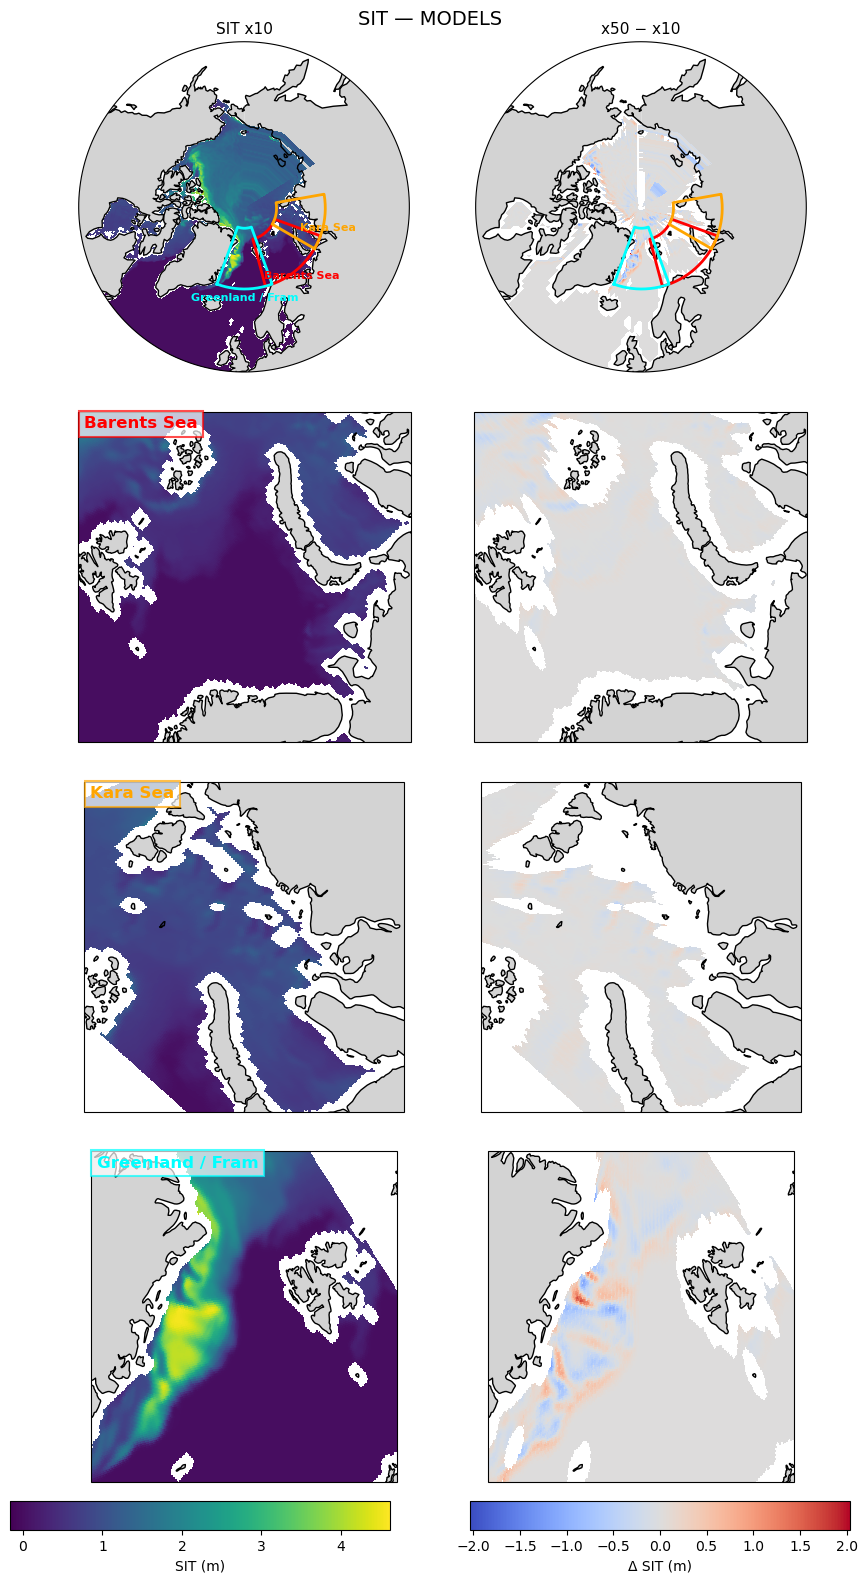

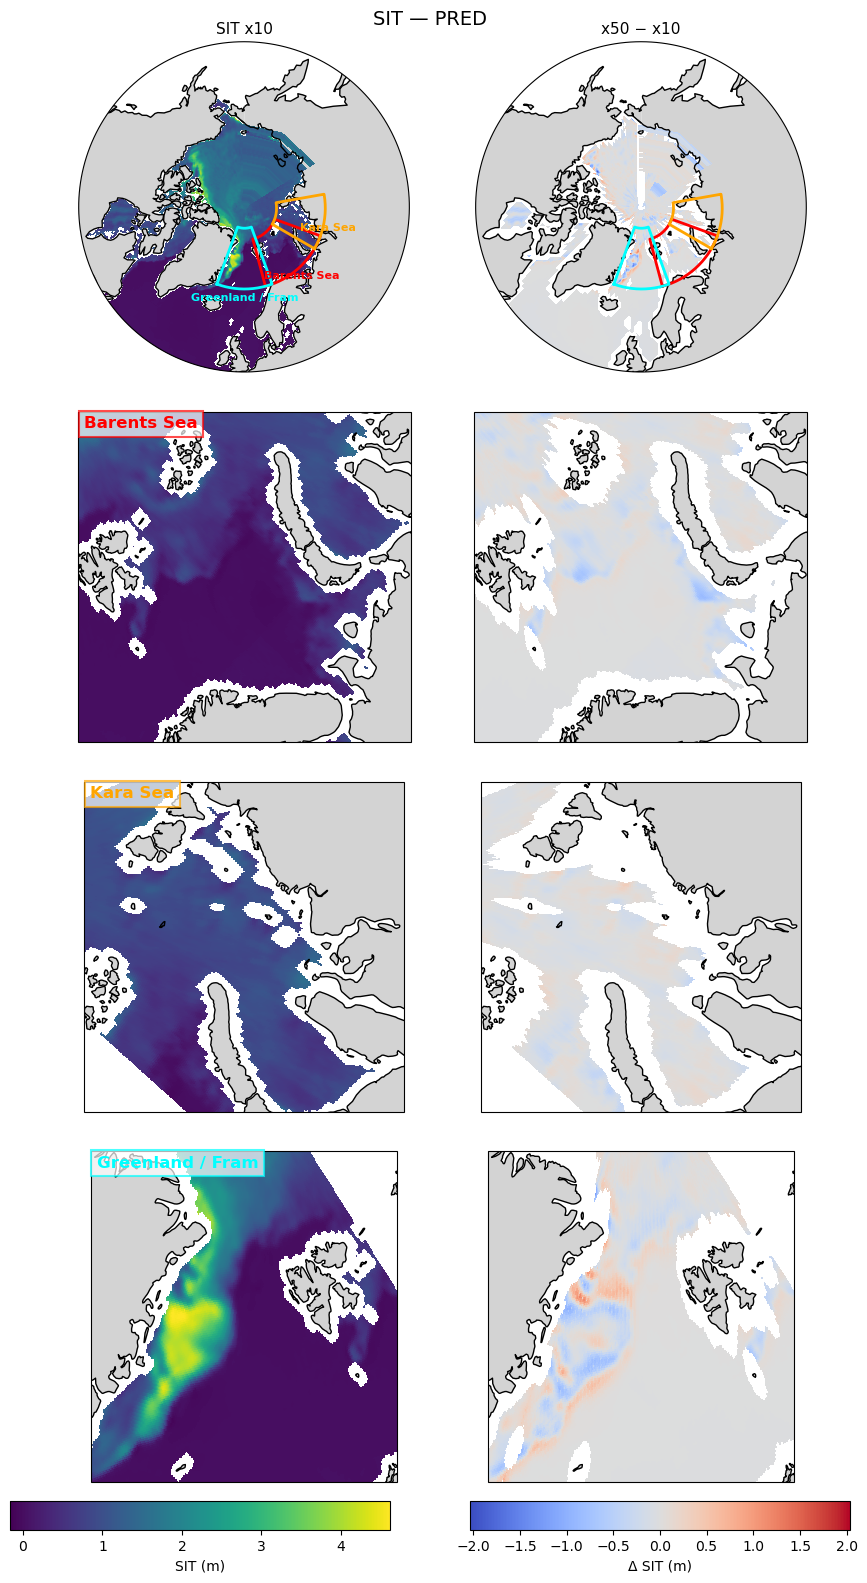

In [22]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.path import Path
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
import time

t_total = time.time()

target_t = -3  # index temporel à sélectionner (-1 = dernier pas de temps)

# -----------------------------
# PATHS
# -----------------------------
base = "/dmidata/users/maxb/results/lightning_logs/version_47352/"
f_x50 = base + "test_data_20210201_20210215_patch_x50.nc"
f_x10 = base + "test_data_20210208_20210215_patch_x10.nc"

# -----------------------------
# LOAD DATA
# -----------------------------
needed_vars = ["lon", "lat", "models_SIT", "pred_SIT"]

def load_ds(path):
    ds = xr.open_dataset(path)
    return ds[[v for v in needed_vars if v in ds]]

ds50 = load_ds(f_x50)
ds10 = load_ds(f_x10)

# -----------------------------
# GRIDS
# -----------------------------
lon50 = (ds50["lon"].values + 180) % 360 - 180
lat50 = ds50["lat"].values

lon10 = (ds10["lon"].values + 180) % 360 - 180
lat10 = ds10["lat"].values

# -----------------------------
# COARSEN
# -----------------------------
def coarsen_field(ds, var, f=4):
    da = ds[var].isel(time=target_t).values
    ny, nx = da.shape
    return da[:ny-ny%f, :nx-nx%f].reshape(ny//f, f, nx//f, f).mean(axis=(1,3))

def coarsen_grid(arr, f=4):
    ny, nx = arr.shape
    return arr[:ny-ny%f, :nx-nx%f].reshape(ny//f, f, nx//f, f).mean(axis=(1,3))

models50_g = coarsen_field(ds50, "models_SIT")
models10_g = coarsen_field(ds10, "models_SIT")

# pred_SIT: use models_SIT as fallback if not present
pred50_g = coarsen_field(ds50, "pred_SIT") if "pred_SIT" in ds50 else models50_g
pred10_g = coarsen_field(ds10, "pred_SIT") if "pred_SIT" in ds10 else models10_g

lon50_g = coarsen_grid(lon50); lat50_g = coarsen_grid(lat50)
lon10_g = coarsen_grid(lon10); lat10_g = coarsen_grid(lat10)

# -----------------------------
# REGRID x50 → x10
# -----------------------------
def regrid(lon_s, lat_s, data_s, lon_t, lat_t):
    return griddata(
        (lon_s.ravel(), lat_s.ravel()),
        data_s.ravel(),
        (lon_t, lat_t),
        method="linear"
    )

models50_on10 = regrid(lon50_g, lat50_g, models50_g, lon10_g, lat10_g)
pred50_on10   = regrid(lon50_g, lat50_g, pred50_g,   lon10_g, lat10_g)

# -----------------------------
# ANOMALIES
# -----------------------------
anom_models_50_10 = models50_on10 - models10_g
anom_pred_50_10   = pred50_on10   - pred10_g

all_anoms = np.concatenate([anom_models_50_10.ravel(), anom_pred_50_10.ravel()])
vmin = float(-1.*np.nanmax(all_anoms))
vmax = float(np.nanmax(all_anoms))

# shared SIT range
sit_all = np.concatenate([models10_g.ravel(), pred10_g.ravel()])
sit_vmin = float(np.nanmin(sit_all))
sit_vmax = float(np.nanmax(sit_all))

# -----------------------------
# REGIONS
# -----------------------------
regions = {
    "Barents Sea":      [15,  70, 70, 82],
    "Kara Sea":         [60, 100, 70, 82],
    "Greenland / Fram": [-20, 20, 70, 85],
}
region_colors = {
    "Barents Sea":      "red",
    "Kara Sea":         "orange",
    "Greenland / Fram": "cyan",
}

# -----------------------------
# ZOOM (KDTree IDW)
# -----------------------------
def make_zoom_grid(extent, pad=12, npts=400):
    lons = np.linspace(extent[0]-pad, extent[1]+pad, npts)
    lats = np.linspace(max(extent[2]-pad, 50), min(extent[3]+pad, 90), npts)
    return np.meshgrid(lons, lats)

def crop_mask(lon, lat, extent, pad=15):
    return ((lat >= extent[2]-pad) & (lat <= extent[3]+pad) &
            (lon >= extent[0]-pad) & (lon <= extent[1]+pad))

def idw_interp(lon_s, lat_s, data_s, lon_t, lat_t, k=20):
    tree = cKDTree(np.column_stack([lon_s, lat_s]))
    dists, idx = tree.query(np.column_stack([lon_t.ravel(), lat_t.ravel()]), k=k)
    dists = np.maximum(dists, 1e-10)
    weights = 1.0 / dists
    weights /= weights.sum(axis=1, keepdims=True)
    return (data_s[idx] * weights).sum(axis=1).reshape(lon_t.shape)

def regrid_zoom(lon_s, lat_s, data_s, extent):
    mask = crop_mask(lon_s, lat_s, extent)
    lo, la, d = lon_s[mask], lat_s[mask], data_s[mask]
    lon_out, lat_out = make_zoom_grid(extent)
    return idw_interp(lo, la, d, lon_out, lat_out), lon_out, lat_out

m50_full    = ds50["models_SIT"].isel(time=target_t).values
m10_full    = ds10["models_SIT"].isel(time=target_t).values
p50_full    = ds50["pred_SIT"].isel(time=target_t).values if "pred_SIT" in ds50 else m50_full
p10_full    = ds10["pred_SIT"].isel(time=target_t).values if "pred_SIT" in ds10 else m10_full

zoom_data = {}
for name, ext in regions.items():
    m50_z, zlon, zlat = regrid_zoom(lon50, lat50, m50_full, ext)
    m10_z, _, _       = regrid_zoom(lon10, lat10, m10_full, ext)
    p50_z, _, _       = regrid_zoom(lon50, lat50, p50_full, ext)
    p10_z, _, _       = regrid_zoom(lon10, lat10, p10_full, ext)
    zoom_data[name] = dict(
        m_main=m10_z, m_anom=m50_z - m10_z,
        p_main=p10_z, p_anom=p50_z - p10_z,
        lon=zlon, lat=zlat,
    )

# -----------------------------
# PLOT HELPERS
# -----------------------------
theta  = np.linspace(0, 2*np.pi, 200)
circle = Path(np.vstack([np.sin(theta)*0.5+0.5, np.cos(theta)*0.5+0.5]).T)
proj   = ccrs.NorthPolarStereo()

def setup_ax(ax, extent=None):
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    else:
        ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
        ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")

def pcolor(ax, lon, lat, data, cmap, vmin, vmax):
    return ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                         cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")

def draw_region_box(ax, extent, color, label=None, lw=2):
    npts = 50
    box_lons = np.concatenate([
        np.linspace(extent[0], extent[1], npts),
        np.full(npts, extent[1]),
        np.linspace(extent[1], extent[0], npts),
        np.full(npts, extent[0]),
    ])
    box_lats = np.concatenate([
        np.full(npts, extent[2]),
        np.linspace(extent[2], extent[3], npts),
        np.full(npts, extent[3]),
        np.linspace(extent[3], extent[2], npts),
    ])
    ax.plot(box_lons, box_lats, color=color, linewidth=lw,
            transform=ccrs.PlateCarree(), zorder=10)
    if label:
        ax.text((extent[0]+extent[1])/2, extent[2]-1, label, color=color,
                fontsize=8, fontweight="bold", ha="center", va="top",
                transform=ccrs.PlateCarree(), zorder=11)

# -----------------------------
# FIGURE FUNCTION  (models or pred)
# -----------------------------
def make_figure_sit(main_g, anom_g, zoom_key_main, zoom_key_anom, title):
    fig, axes = plt.subplots(4, 2, figsize=(10, 16),
                             subplot_kw={"projection": proj})

    # --- Global row ---
    setup_ax(axes[0, 0])
    setup_ax(axes[0, 1])
    im0 = pcolor(axes[0, 0], lon10_g, lat10_g, main_g,  "viridis",  sit_vmin, sit_vmax)
    im1 = pcolor(axes[0, 1], lon10_g, lat10_g, anom_g,  "coolwarm", vmin,     vmax)
    for rname, ext in regions.items():
        col = region_colors[rname]
        draw_region_box(axes[0, 0], ext, col, label=rname)
        draw_region_box(axes[0, 1], ext, col)
    axes[0, 0].set_title("SIT x10",    fontsize=11)
    axes[0, 1].set_title("x50 − x10", fontsize=11)

    # --- Zoom rows ---
    for i, (rname, rd) in enumerate(zoom_data.items(), start=1):
        col = region_colors[rname]
        setup_ax(axes[i, 0], regions[rname])
        setup_ax(axes[i, 1], regions[rname])
        pcolor(axes[i, 0], rd["lon"], rd["lat"], rd[zoom_key_main], "viridis",  sit_vmin, sit_vmax)
        pcolor(axes[i, 1], rd["lon"], rd["lat"], rd[zoom_key_anom], "coolwarm", vmin,     vmax)
        axes[i, 0].text(0.02, 0.95, rname, color=col, fontsize=12, weight="bold",
                        transform=axes[i, 0].transAxes,
                        bbox=dict(facecolor="white", alpha=0.7, edgecolor=col, lw=1.5))

    # --- Colorbars ---
    cax1 = fig.add_axes([0.08, 0.04, 0.38, 0.018])
    fig.colorbar(im0, cax=cax1, orientation="horizontal").set_label("SIT (m)")
    cax2 = fig.add_axes([0.54, 0.04, 0.38, 0.018])
    fig.colorbar(im1, cax=cax2, orientation="horizontal").set_label("Δ SIT (m)")

    fig.suptitle(title, fontsize=14, y=0.99)
    plt.subplots_adjust(hspace=0.12, wspace=0.05, top=0.97, bottom=0.07)
    return fig

# -----------------------------
# RUN — two figures: MODELS and PRED
# -----------------------------
fig_models = make_figure_sit(models10_g, anom_models_50_10,
                             "m_main", "m_anom", "SIT — MODELS")
fig_pred   = make_figure_sit(pred10_g,   anom_pred_50_10,
                             "p_main", "p_anom", "SIT — PRED")

print(f"TOTAL: {time.time()-t_total:.2f}s")
plt.show()


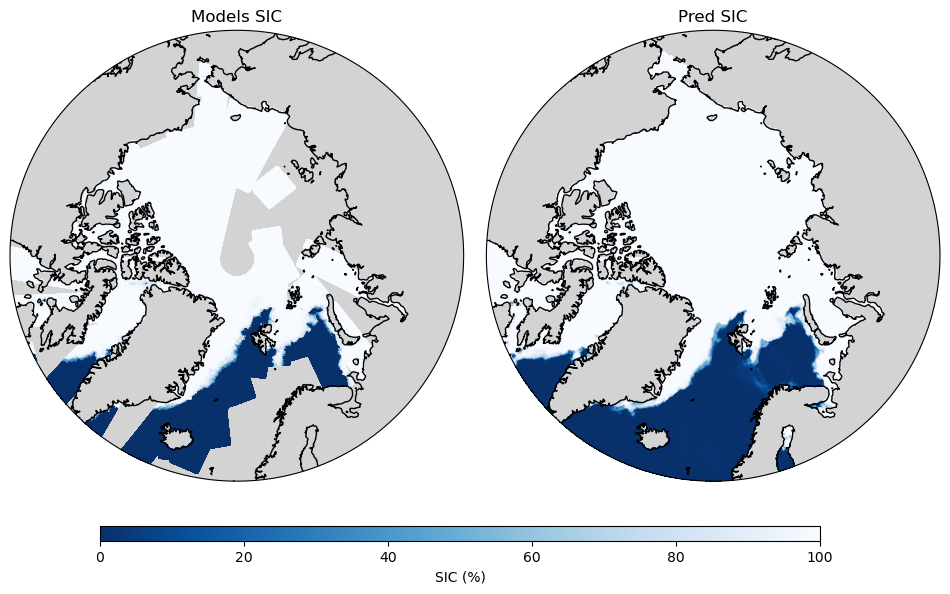

In [39]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.path import Path

# Load pred_SIC (same slice as models_SIC)
f_x2 = "/dmidata/users/maxb/results/lightning_logs/version_75990/test_data_20210211_20210215_patch_x2.nc"
needed_vars = ["lon", "lat", "pred_SIC", "tgt_SIC"]
ds = load_ds(f_x2)
pred_SIC = ds.pred_SIC.isel(time=-1).values
tgt_SIC = ds.tgt_SIC.isel(time=-1).values

lon = ds.lon.values
lat = ds.lat.values
theta = np.linspace(0, 2*np.pi, 200)
circle_path = Path(np.vstack([np.sin(theta)*0.5+0.5, np.cos(theta)*0.5+0.5]).T)

# Shared color range
sic_all = np.concatenate([tgt_SIC[np.isfinite(tgt_SIC)], pred_SIC[np.isfinite(pred_SIC)]])
vmin_sic = float(np.nanmin(sic_all))
vmax_sic = float(np.nanmax(sic_all))

proj = ccrs.NorthPolarStereo()
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": proj})

for ax in axes:
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.set_facecolor("lightgray")
    ax.set_boundary(circle_path, transform=ax.transAxes)

mask_m = np.isfinite(tgt_SIC)
sc_m = axes[0].scatter(lon[mask_m], lat[mask_m], c=tgt_SIC[mask_m], s=2,
                        cmap="Blues_r", vmin=vmin_sic, vmax=vmax_sic,
                        transform=ccrs.PlateCarree())
axes[0].set_title("Models SIC")

mask_p = np.isfinite(pred_SIC)
sc_p = axes[1].scatter(lon[mask_p], lat[mask_p], c=pred_SIC[mask_p],  s=2,
                        cmap="Blues_r", vmin=vmin_sic, vmax=vmax_sic,
                        transform=ccrs.PlateCarree())
axes[1].set_title("Pred SIC")

cax = fig.add_axes([0.2, 0.04, 0.6, 0.025])
fig.colorbar(sc_m, cax=cax, orientation="horizontal").set_label("SIC (%)")

plt.subplots_adjust(top=0.93, bottom=0.10, wspace=0.05)
plt.show()


(1474, 1520)
(1474, 1520)


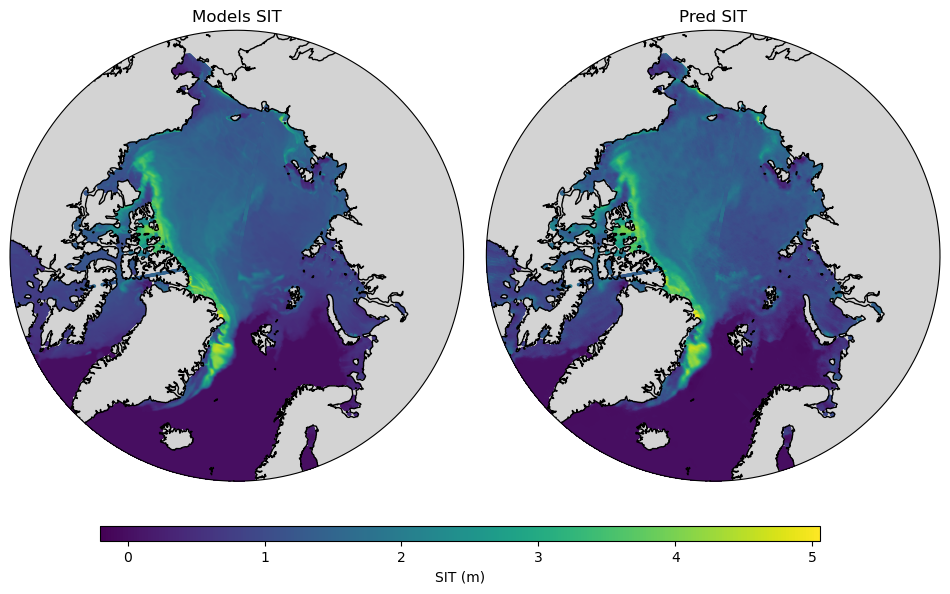

In [18]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.path import Path

# Load pred_SIT (same slice as models_SIT)
f_x10 = base + "test_data_20210208_20210215_patch_x10.nc"
needed_vars = ["lon", "lat", "models_SIT", "pred_SIT"]
ds = load_ds(f_x10)
pred_SIT = ds.pred_SIT.isel(time=-1).values
models_SIT = ds.models_SIT.isel(time=-1).values
lon = ds.lon.values
lat = ds.lat.values

theta = np.linspace(0, 2*np.pi, 200)
circle_path = Path(np.vstack([np.sin(theta)*0.5+0.5, np.cos(theta)*0.5+0.5]).T)

# Shared color range
sit_all = np.concatenate([models_SIT[np.isfinite(models_SIT)], pred_SIT[np.isfinite(pred_SIT)]])
vmin_sit = float(np.nanmin(sit_all))
vmax_sit = float(np.nanmax(sit_all))

proj = ccrs.NorthPolarStereo()
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": proj})

for ax in axes:
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.set_facecolor("lightgray")
    ax.set_boundary(circle_path, transform=ax.transAxes)

mask_m = np.isfinite(models_SIT)
print(models_SIT.shape)
sc_m = axes[0].scatter(lon[mask_m], lat[mask_m], c=models_SIT[mask_m], s=2,
                        cmap="viridis", vmin=vmin_sit, vmax=vmax_sit,
                        transform=ccrs.PlateCarree())
axes[0].set_title("Models SIT")

print(lon.shape)
mask_p = np.isfinite(pred_SIT)
sc_p = axes[1].scatter(lon[mask_p], lat[mask_p], c=pred_SIT[mask_p], s=2,
                        cmap="viridis", vmin=vmin_sit, vmax=vmax_sit,
                        transform=ccrs.PlateCarree())
axes[1].set_title("Pred SIT")

cax = fig.add_axes([0.2, 0.04, 0.6, 0.025])
fig.colorbar(sc_m, cax=cax, orientation="horizontal").set_label("SIT (m)")

plt.subplots_adjust(top=0.93, bottom=0.10, wspace=0.05)
plt.show()
